## 1. Load the Dataset

The baseline model notebook starts from the original SMS Spam Collection dataset.

The raw dataset contains:
- `v1` → message label
- `v2` → SMS message
- extra unnamed columns → empty columns that will be removed

We will recreate the required preprocessing pipeline in this notebook so that the notebook can run independently.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 2. Clean the Raw Dataset

The original dataset contains several unnamed columns that do not contain useful information.

We will:
1. Keep only the label and message columns.
2. Rename them to `label` and `message`.
3. Convert the labels into numerical values:
   - `ham` → `0`
   - `spam` → `1`

In [2]:
df = df[["v1", "v2"]]

df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. Recreate the Text Preprocessing Pipeline

The model should not receive raw SMS messages directly.

We will apply the preprocessing steps learned previously:

1. Convert text to lowercase
2. Remove punctuation
3. Tokenize the text
4. Remove stopwords
5. Apply stemming
6. Join the processed tokens back into text

The resulting text will be stored in `transformed_text`.

In [3]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words("english"))
ps = PorterStemmer()


def transform_text(text):
    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    words = [
        ps.stem(word)
        for word in words
    ]

    return " ".join(words)

In [4]:
df["transformed_text"] = df["message"].apply(transform_text)

df[["message", "transformed_text"]].head()

,message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## 4. Convert Text into TF-IDF Features

Machine learning models cannot directly understand text.

TF-IDF converts each processed SMS message into a numerical vector.

Each column represents a word from the vocabulary, and each value represents how important that word is to a particular message.

We will use the same TF-IDF approach explored in the previous notebook.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["transformed_text"])

X.shape

(5572, 6221)

## 5. Create the Target Variable

`X` contains our numerical text features.

`y` contains the target labels:

- `0` → ham
- `1` → spam

In [6]:
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLabel distribution:")
print(y.value_counts())

X shape: (5572, 6221)
y shape: (5572,)

Label distribution:
label
0    4825
1     747
Name: count, dtype: int64


## 6. Create the Train/Test Split

We will divide the dataset into:

- 80% training data
- 20% testing data

`stratify=y` preserves the original ham/spam distribution in both sets.

`random_state=42` makes the split reproducible.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4457, 6221)
X_test : (1115, 6221)
y_train: (4457,)
y_test : (1115,)


In [9]:
print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training labels:
label
0    3859
1     598
Name: count, dtype: int64

Testing labels:
label
0    966
1    149
Name: count, dtype: int64


## 7. Train the Baseline Model — Multinomial Naive Bayes

We now have:

- `X_train` → TF-IDF features used for training
- `X_test` → TF-IDF features used for testing
- `y_train` → training labels
- `y_test` → testing labels

Our first machine learning model will be **Multinomial Naive Bayes**.

Naive Bayes is a probabilistic classification algorithm that works particularly well with text data.

The model will learn patterns from the training messages and then predict whether unseen messages are:

- `0` → ham
- `1` → spam

This model will serve as our baseline. Later models can be compared against its performance.

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

### Train the Naive Bayes Model

The model will now learn the relationship between the TF-IDF features in `X_train` and their corresponding labels in `y_train`.

Only the training data is used during this step.

The test data will remain unseen until evaluation.

In [11]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 6221)","[[0.37,0.62,0.08,...,0. ,0. ,0.16], [0. ,0. ,0. ,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 6221)","[[-9.35,-9.18,-9.58,...,-9.66,-9.66,-9.51], [-9.03,-9.03,-9.03,...,-9.03,-9.03,-9.03]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6221


### Make Predictions on the Test Set

The model has now learned from the training data.

We will use the trained model to predict the labels of the unseen test messages stored in `X_test`.

The predictions will be compared with the actual labels in `y_test` during evaluation.

In [12]:
y_pred = nb_model.predict(X_test)

y_pred[:20]

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Evaluate the Baseline Model — Accuracy

Accuracy measures the proportion of test messages that the model classified correctly.

\[
Accuracy = \frac{Correct\ Predictions}{Total\ Predictions}
\]

Although accuracy is useful as a first metric, it should not be our only metric because our dataset is imbalanced between ham and spam.

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9686
Accuracy: 96.86%


### Confusion Matrix

A confusion matrix shows how the model's predictions compare with the actual labels.

For our binary classification problem:

- `0` = ham
- `1` = spam

The four possible outcomes are:

- **True Negative (TN):** Ham correctly classified as ham
- **False Positive (FP):** Ham incorrectly classified as spam
- **False Negative (FN):** Spam incorrectly classified as ham
- **True Positive (TP):** Spam correctly classified as spam

This allows us to understand the types of mistakes made by the classifier.

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 35 114]]


### Precision, Recall and F1-Score

Accuracy alone is not enough for our spam detection problem because the dataset is imbalanced.

We therefore evaluate the model using:

#### Precision

Precision answers:

> Of all messages predicted as spam, how many were actually spam?

\[
Precision = \frac{TP}{TP + FP}
\]

A high precision means the model does not incorrectly mark many legitimate messages as spam.

#### Recall

Recall answers:

> Of all the actual spam messages, how many did the model successfully detect?

\[
Recall = \frac{TP}{TP + FN}
\]

A high recall means the model misses fewer spam messages.

#### F1-Score

F1-score combines precision and recall into a single metric.

\[
F1 = 2 \times \frac{Precision \times Recall}
{Precision + Recall}
\]

It is useful when we want a balance between detecting spam and avoiding false spam alerts.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Precision: 1.0000
Recall:    0.7651
F1-Score:  0.8669


### Visualize the Confusion Matrix

The numerical confusion matrix shows the four prediction outcomes.

A heatmap makes these outcomes easier to interpret visually.

The matrix layout is:

|              | Predicted Ham | Predicted Spam |
|--------------|---------------|----------------|
| Actual Ham   | TN            | FP             |
| Actual Spam  | FN            | TP             |

This helps us clearly see which type of classification error the model makes.

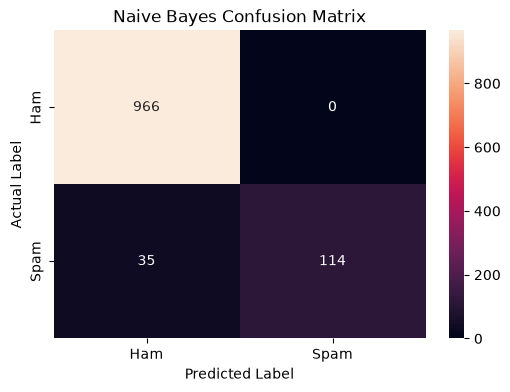

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

## Error Analysis

A confusion matrix tells us how many predictions were correct and incorrect,
but it does not tell us *which messages* were misclassified.

We will inspect the spam messages that the Naive Bayes model incorrectly
classified as ham.

These false negatives are important because they represent spam messages
that the classifier failed to detect.

In [18]:
print(df.columns.tolist())

['label', 'message', 'transformed_text']


In [19]:
# Find spam messages that were incorrectly predicted as ham

false_negative_mask = (y_test.to_numpy() == 1) & (y_pred == 0)

false_negative_indices = y_test.index[false_negative_mask]

false_negatives = df.loc[false_negative_indices]

false_negatives[["label", "message"]].head(20)

,label,message
5,1,FreeMsg Hey there darling it's been 3 week's n...
1021,1,Guess what! Somebody you know secretly fancies...
3748,1,Dear Voucher Holder 2 claim your 1st class air...
855,1,Talk sexy!! Make new friends or fall in love i...
3139,1,sexy sexy cum and text me im wet and warm and ...
1662,1,Hi if ur lookin 4 saucy daytime fun wiv busty ...
3979,1,ringtoneking 84484
3358,1,Sorry I missed your call let's talk when you h...
5449,1,"Latest News! Police station toilet stolen, cop..."
1268,1,Can U get 2 phone NOW? I wanna chat 2 set up m...


## Final Baseline Model Evaluation

The Multinomial Naive Bayes classifier serves as our first baseline
machine learning model for the SMS spam classification task.

The model was trained using TF-IDF features and evaluated on a held-out
test set.

We evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The goal of this baseline is not to achieve the best possible result,
but to establish a measurable starting point that future models can
be compared against.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Baseline Model Performance =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

===== Baseline Model Performance =====
Accuracy : 0.9686
Precision: 1.0000
Recall   : 0.7651
F1-Score : 0.8669


### Baseline Interpretation

The baseline Naive Bayes model achieves high precision, meaning that
messages predicted as spam are very likely to actually be spam.

However, recall is lower than precision. The confusion matrix shows
that 35 spam messages were incorrectly classified as ham.

Therefore, the main weakness of this baseline is false negatives:
some spam messages are not detected.

This baseline will be used as the reference point for future models
and improvements.

## Saving the Baseline Model Artifacts

We save both the trained classifier and the TF-IDF vectorizer.

The vectorizer is required because the model expects numerical TF-IDF
features rather than raw text.

Saving both artifacts allows us to reuse the complete prediction pipeline
later without retraining the model.

In [21]:
import os
import joblib

# Create directory for trained model artifacts
os.makedirs("../models", exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

# Save Naive Bayes model
joblib.dump(nb_model, "../models/naive_bayes_model.pkl")

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [22]:
print(os.listdir("../models"))

['.gitkeep', 'naive_bayes_model.pkl', 'tfidf_vectorizer.pkl']
